# 04 — Balanceamento de Classes
**Projeto:** Give Me Some Credit — Classificação de Risco de Crédito  
**Notebook:** `04_balanceamento.ipynb`  
**Autor:** Eduardo EMF  
**Repositório:** [credit-risk-classifier](https://github.com/eduardoemf/credit-risk-classifier)

---

## 🎯 Objetivo

O dataset apresenta **desbalanceamento severo**: ~93,3% adimplentes (classe 0) vs ~6,7% inadimplentes (classe 1).

Este notebook tem **uma responsabilidade única**: escolher e justificar a estratégia de balanceamento, e exportar o dataset de treino com as classes equilibradas para uso em `05_modelagem.ipynb`.

### Por que balancear gerando novos dados?

Existem duas famílias de abordagens para lidar com o desbalanceamento:

| Família | Exemplos | O que faz |
|---|---|---|
| **Ajuste de peso** | `class_weight='balanced'` | Penaliza erros na minoria durante o treino, mas **não altera os dados** |
| **Reamostramento** | SMOTE, Undersampling, SMOTETomek | **Transforma o dataset** — mais ou menos registros de cada classe |

Para este projeto, a escolha é por **reamostramento via SMOTE** — queremos que o arquivo de treino entregue ao `05_modelagem.ipynb` tenha as classes equilibradas em ~50%, tornando o efeito do balanceamento explícito, rastreável e independente do algoritmo de modelagem utilizado.

O experimento comparativo a seguir documenta por que SMOTE é a abordagem mais adequada para este problema.

---

## ⚙️ Configuração do Ambiente

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import json, os, warnings
warnings.filterwarnings('ignore')

# Modelo proxy e métricas
from sklearn.linear_model    import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.metrics         import (
    roc_auc_score, f1_score, recall_score, precision_score,
    average_precision_score, confusion_matrix,
    roc_curve, precision_recall_curve,
)

# Balanceamento
from imblearn.over_sampling  import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine        import SMOTETomek
from imblearn.pipeline       import Pipeline as ImbPipeline

# ── Opções de exibição ──────────────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

# ── Tema visual padronizado ─────────────────────────────────────────
PALETTE_MAIN     = 'steelblue'
PALETTE_TARGET   = {0: '#5b9bd5', 1: '#d9534f'}
COLOR_0, COLOR_1 = '#5b9bd5', '#d9534f'

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.figsize'   : (12, 5),
    'figure.dpi'       : 110,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

RANDOM_STATE   = 42
CHOSEN_STRATEGY = 'SMOTE'   # estratégia definida por critério de negócio

---

## 1. Carregamento dos Dados

In [2]:
df = pd.read_parquet('../data/processed/cs-training_features.parquet')

print(f'Dimensões: {df.shape[0]:,} linhas × {df.shape[1]} colunas')
df.head()

Dimensões: 149,999 linhas × 21 colunas


,target_default_2y,revolving_utilization,age,debt_ratio,monthly_income,num_credit_lines,late_30_59_days,late_60_89_days,late_90_plus_days,num_real_estate_loans,num_dependents,log_monthly_income,log_debt_ratio,total_late_occurrences,has_any_late,max_late_severity,util_x_late90,debt_to_income_stress,income_per_dependent,age_group,credit_util_bin
0,1,0.7661,45,0.8030,9120.0000,13,2,0,0,6,2,9.1183,0.5894,2,1,2,0.0000,0.6152,3040.0000,40–49,Alta (60–90%)
1,0,0.9572,40,0.1219,2600.0000,4,0,0,0,0,1,7.8637,0.1150,0,0,0,0.0000,0.1167,1300.0000,40–49,Crítica (90–100%)
2,0,0.6582,38,0.0851,3042.0000,2,1,0,1,0,0,8.0206,0.0817,2,1,1,0.6582,0.0560,3042.0000,30–39,Alta (60–90%)
3,0,0.2338,30,0.0360,3300.0000,5,0,0,0,0,0,8.1020,0.0354,0,0,0,0.0000,0.0084,3300.0000,30–39,Baixa (0–30%)
4,0,0.9072,49,0.0249,23000.0000,7,1,0,0,1,0,10.0433,0.0246,1,1,1,0.0000,0.0226,23000.0000,40–49,Crítica (90–100%)


In [3]:
FEATURES = [
    'revolving_utilization', 'age', 'debt_ratio', 'monthly_income',
    'num_credit_lines', 'late_30_59_days', 'late_60_89_days',
    'late_90_plus_days', 'num_real_estate_loans', 'num_dependents',
    'log_monthly_income', 'log_debt_ratio', 'total_late_occurrences',
    'has_any_late', 'max_late_severity', 'util_x_late90',
    'debt_to_income_stress', 'income_per_dependent',
]
TARGET = 'target_default_2y'

X = df[FEATURES].copy()
y = df[TARGET].copy()

vc = y.value_counts()
vn = y.value_counts(normalize=True).mul(100).round(2)

print(f'Features: {len(FEATURES)}   |   Amostras: {X.shape[0]:,}')
print()
print('Distribuição original do target:')
for cls in [0, 1]:
    label = 'Adimplente' if cls == 0 else 'Inadimplente'
    print(f'  Classe {cls} ({label}): {vc[cls]:,}  ({vn[cls]}%)')
print(f'\nRazão de desbalanceamento: {vc[0]/vc[1]:.1f}:1')

Features: 18   |   Amostras: 149,999

Distribuição original do target:
  Classe 0 (Adimplente): 139,973  (93.32%)
  Classe 1 (Inadimplente): 10,026  (6.68%)

Razão de desbalanceamento: 14.0:1


---

## 2. Por que Acurácia Não é a Métrica Correta

Antes de comparar estratégias, demonstramos numericamente o problema central do desbalanceamento.

In [4]:
y_naive = np.zeros(len(y), dtype=int)

print('Modelo ingênuo — sempre prevê adimplente (classe 0):')
print(f'  Acurácia:        {(y_naive == y).mean():.4f}  ← parece excelente')
print(f'  Recall cl. 1:    {recall_score(y, y_naive, zero_division=0):.4f}  ← detecta 0% dos inadimplentes')
print(f'  F1 cl. 1:        {f1_score(y, y_naive, zero_division=0):.4f}  ← inútil para o negócio')
print(f'  AUC-ROC:         {roc_auc_score(y, y_naive):.4f}  ← equivale a chute aleatório')
print()
print('→ 93%+ de acurácia sem detectar nenhum inadimplente.')
print('  Métricas decisórias: AUC-ROC, PR-AUC, F1 e Recall da classe 1.')

Modelo ingênuo — sempre prevê adimplente (classe 0):
  Acurácia:        0.9332  ← parece excelente
  Recall cl. 1:    0.0000  ← detecta 0% dos inadimplentes
  F1 cl. 1:        0.0000  ← inútil para o negócio
  AUC-ROC:         0.5000  ← equivale a chute aleatório

→ 93%+ de acurácia sem detectar nenhum inadimplente.
  Métricas decisórias: AUC-ROC, PR-AUC, F1 e Recall da classe 1.


> Em concessão de crédito, um **Falso Negativo** (inadimplente aprovado) representa perda financeira direta e imediata.  
> O modelo precisa ser avaliado por sua capacidade de **identificar inadimplentes**, não por taxa de acerto geral.

---

## 3. Comparação das Estratégias de Balanceamento

Avaliamos cinco abordagens usando **Regressão Logística como modelo proxy** — sensível ao desbalanceamento, rápida e interpretável, ideal para isolar o efeito do balanceamento sem introduzir a variabilidade dos modelos complexos do `05`.

**Protocolo:** `StratifiedKFold` com 5 folds + `cross_val_predict` com probabilidades out-of-fold.  
O reamostrador é aplicado **dentro de cada fold de treino** via `ImbPipeline` — nunca no fold de validação, garantindo ausência de data leakage.

In [5]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}

def run_strategy(name, pipeline):
    """Avalia uma estratégia via cross_val_predict e registra as métricas."""
    y_proba = cross_val_predict(pipeline, X, y, cv=CV, method='predict_proba')[:, 1]
    y_pred  = (y_proba >= 0.5).astype(int)

    m = {
        'AUC-ROC'          : roc_auc_score(y, y_proba),
        'PR-AUC'           : average_precision_score(y, y_proba),
        'F1 (classe 1)'    : f1_score(y, y_pred, pos_label=1),
        'Recall (cl. 1)'   : recall_score(y, y_pred, pos_label=1),
        'Precision (cl. 1)': precision_score(y, y_pred, pos_label=1, zero_division=0),
        'F1 (classe 0)'    : f1_score(y, y_pred, pos_label=0),
        'y_proba'          : y_proba,
    }
    results[name] = m

    marker = '⭐' if name == CHOSEN_STRATEGY else '  '
    print(f'{marker} {name:<22}  AUC-ROC: {m["AUC-ROC"]:.4f} | '
          f'PR-AUC: {m["PR-AUC"]:.4f} | '
          f'F1 cl.1: {m["F1 (classe 1)"]:.4f} | '
          f'Recall cl.1: {m["Recall (cl. 1)"]:.4f}')
    return m

print('Executando experimento comparativo...')
print()

Executando experimento comparativo...



### 3.1 Baseline — Sem Tratamento

In [6]:
run_strategy('Baseline', Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
]))

   Baseline                AUC-ROC: 0.8579 | PR-AUC: 0.3787 | F1 cl.1: 0.2446 | Recall cl.1: 0.1529


{'AUC-ROC': 0.8578871717628243,
 'PR-AUC': 0.37865338927455267,
 'F1 (classe 1)': 0.24459513362584762,
 'Recall (cl. 1)': 0.15290245362058646,
 'Precision (cl. 1)': 0.6110003985651654,
 'F1 (classe 0)': 0.9670601086052814,
 'y_proba': array([0.39072176, 0.08453772, 0.21267049, ..., 0.01727542, 0.01195246,
        0.0586034 ], shape=(149999,))}

### 3.2 `class_weight='balanced'`

In [7]:
run_strategy('Class Weight', Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(class_weight='balanced', max_iter=1000,
                                  random_state=RANDOM_STATE)),
]))

   Class Weight            AUC-ROC: 0.8586 | PR-AUC: 0.3771 | F1 cl.1: 0.3338 | Recall cl.1: 0.7608


{'AUC-ROC': 0.858645001509788,
 'PR-AUC': 0.3771141004781982,
 'F1 (classe 1)': 0.33377089349785594,
 'Recall (cl. 1)': 0.7608218631557949,
 'Precision (cl. 1)': 0.21377725463819292,
 'F1 (classe 0)': 0.8802469621298518,
 'y_proba': array([0.90756744, 0.56948342, 0.80014762, ..., 0.20427265, 0.14225793,
        0.4595182 ], shape=(149999,))}

### 3.3 SMOTE ⭐ Estratégia Selecionada

In [8]:
run_strategy('SMOTE', ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote',  SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
    ('clf',    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
]))

⭐ SMOTE                   AUC-ROC: 0.8583 | PR-AUC: 0.3765 | F1 cl.1: 0.3324 | Recall cl.1: 0.7603


{'AUC-ROC': 0.8582879992576267,
 'PR-AUC': 0.37650165165643695,
 'F1 (classe 1)': 0.33235236413576613,
 'Recall (cl. 1)': 0.7603231597845601,
 'Precision (cl. 1)': 0.2126537785588752,
 'F1 (classe 0)': 0.8794805705853419,
 'y_proba': array([0.90839233, 0.57793359, 0.80528959, ..., 0.20273994, 0.14459288,
        0.46263585], shape=(149999,))}

### 3.4 RandomUnderSampler

In [9]:
run_strategy('Undersampling', ImbPipeline([
    ('scaler', StandardScaler()),
    ('under',  RandomUnderSampler(random_state=RANDOM_STATE)),
    ('clf',    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
]))

   Undersampling           AUC-ROC: 0.8583 | PR-AUC: 0.3757 | F1 cl.1: 0.3332 | Recall cl.1: 0.7601


{'AUC-ROC': 0.8582665173853617,
 'PR-AUC': 0.3757363368489396,
 'F1 (classe 1)': 0.33323859288572116,
 'Recall (cl. 1)': 0.7601236784360662,
 'Precision (cl. 1)': 0.2133956822445608,
 'F1 (classe 0)': 0.8800553766041713,
 'y_proba': array([0.89788854, 0.56879594, 0.7822767 , ..., 0.22436804, 0.13734153,
        0.45942364], shape=(149999,))}

### 3.5 SMOTETomek

In [10]:
run_strategy('SMOTETomek', ImbPipeline([
    ('scaler',  StandardScaler()),
    ('hybrid',  SMOTETomek(random_state=RANDOM_STATE)),
    ('clf',     LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
]))

   SMOTETomek              AUC-ROC: 0.8583 | PR-AUC: 0.3766 | F1 cl.1: 0.3322 | Recall cl.1: 0.7590


{'AUC-ROC': 0.8582595206525602,
 'PR-AUC': 0.376559102801457,
 'F1 (classe 1)': 0.3322346161402283,
 'Recall (cl. 1)': 0.7590265310193497,
 'Precision (cl. 1)': 0.21265893530809,
 'F1 (classe 0)': 0.8796515950855079,
 'y_proba': array([0.91058454, 0.57852641, 0.80977765, ..., 0.1977562 , 0.14119173,
        0.46166613], shape=(149999,))}

---

## 4. Comparação Visual das Estratégias

### 4.1 Tabela de Métricas

In [11]:
METRIC_KEYS = ['AUC-ROC', 'PR-AUC', 'F1 (classe 1)',
               'Recall (cl. 1)', 'Precision (cl. 1)', 'F1 (classe 0)']

comparison = pd.DataFrame(
    {name: {k: v for k, v in m.items() if k in METRIC_KEYS}
     for name, m in results.items()}
).T.sort_values('AUC-ROC', ascending=False)

# Score composto
WEIGHTS = {'AUC-ROC': 0.30, 'PR-AUC': 0.25, 'F1 (classe 1)': 0.25, 'Recall (cl. 1)': 0.20}
comparison['Score Composto'] = sum(comparison[k] * w for k, w in WEIGHTS.items())

def highlight_row(row):
    color = 'background-color: #fff3cd; font-weight: bold' if row.name == CHOSEN_STRATEGY else ''
    return [color] * len(row)

def highlight_best_col(s):
    return ['font-weight: bold; color: #155724'
            if v == s.max() else '' for v in s]

(comparison.style
    .apply(highlight_row, axis=1)
    .apply(highlight_best_col, subset=METRIC_KEYS + ['Score Composto'])
    .format('{:.4f}'))

,AUC-ROC,PR-AUC,F1 (classe 1),Recall (cl. 1),Precision (cl. 1),F1 (classe 0),Score Composto
Class Weight,0.8586,0.3771,0.3338,0.7608,0.2138,0.8802,0.5875
SMOTE,0.8583,0.3765,0.3324,0.7603,0.2127,0.8795,0.5868
Undersampling,0.8583,0.3757,0.3332,0.7601,0.2134,0.8801,0.5867
SMOTETomek,0.8583,0.3766,0.3322,0.7590,0.2127,0.8797,0.5865
Baseline,0.8579,0.3787,0.2446,0.1529,0.6110,0.9671,0.4438


> Linha em amarelo = estratégia selecionada (SMOTE). Valores em verde = melhor por coluna.

### 4.2 Gráfico Comparativo

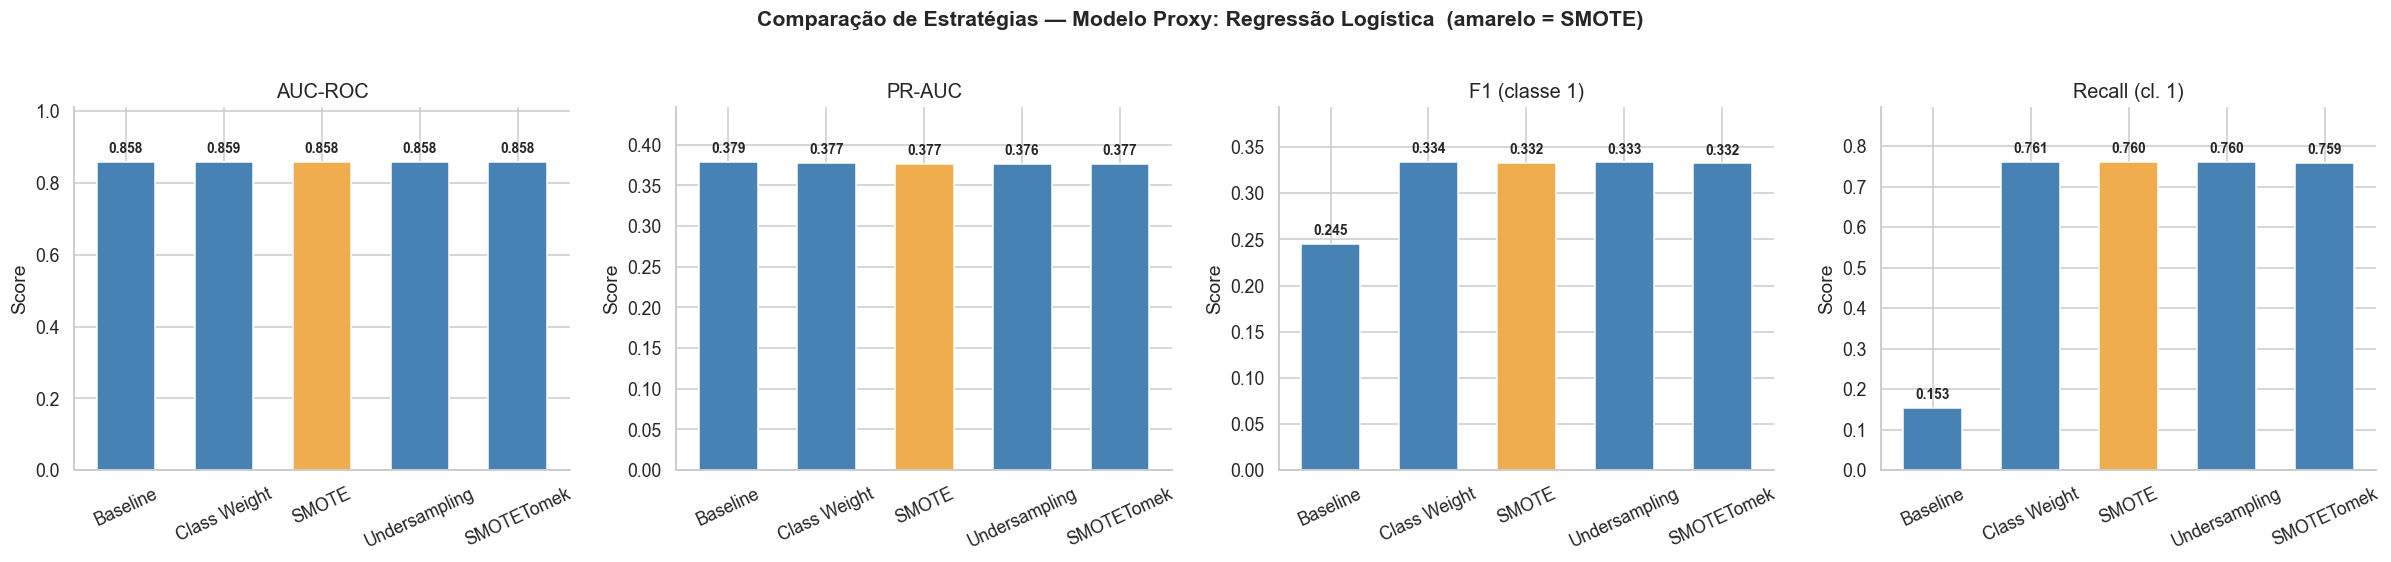

In [12]:
plot_metrics = ['AUC-ROC', 'PR-AUC', 'F1 (classe 1)', 'Recall (cl. 1)']
palette      = sns.color_palette('Set2', len(results))

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, metric in zip(axes, plot_metrics):
    values = [results[s][metric] for s in results]
    labels = list(results.keys())
    colors = ['#f0ad4e' if lbl == CHOSEN_STRATEGY else PALETTE_MAIN
              for lbl in labels]

    bars = ax.bar(labels, values, color=colors, edgecolor='white', width=0.6)
    ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=9, fontweight='bold')
    ax.set_title(metric, fontsize=13)
    ax.set_ylim(0, min(1.08, max(values) * 1.18))
    ax.tick_params(axis='x', rotation=25)
    ax.set_ylabel('Score')

plt.suptitle(f'Comparação de Estratégias — Modelo Proxy: Regressão Logística  '
             f'(amarelo = {CHOSEN_STRATEGY})',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.3 Curvas ROC e Precision-Recall

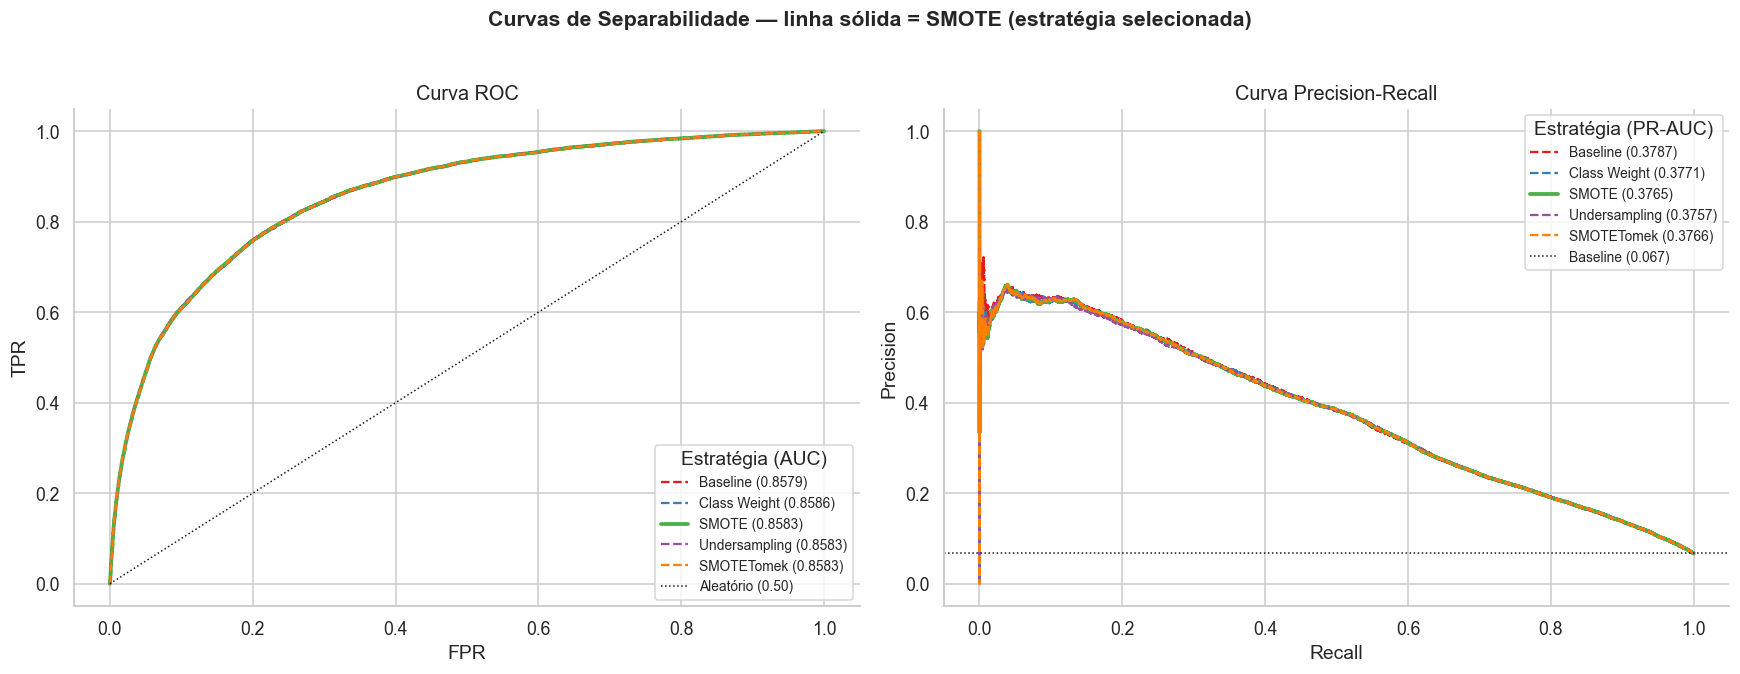

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette_roc = sns.color_palette('Set1', len(results))

for (name, m), color in zip(results.items(), palette_roc):
    lw   = 2.5 if name == CHOSEN_STRATEGY else 1.5
    ls   = '-' if name == CHOSEN_STRATEGY else '--'

    fpr, tpr, _ = roc_curve(y, m['y_proba'])
    axes[0].plot(fpr, tpr, lw=lw, ls=ls, color=color,
                 label=f'{name} ({m["AUC-ROC"]:.4f})')

    prec, rec, _ = precision_recall_curve(y, m['y_proba'])
    axes[1].plot(rec, prec, lw=lw, ls=ls, color=color,
                 label=f'{name} ({m["PR-AUC"]:.4f})')

axes[0].plot([0,1],[0,1], 'k:', lw=1, label='Aleatório (0.50)')
axes[0].set_title('Curva ROC', fontsize=13)
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].legend(fontsize=9, title='Estratégia (AUC)')

axes[1].axhline(y.mean(), color='k', ls=':', lw=1,
                label=f'Baseline ({y.mean():.3f})')
axes[1].set_title('Curva Precision-Recall', fontsize=13)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=9, title='Estratégia (PR-AUC)')

plt.suptitle('Curvas de Separabilidade — linha sólida = SMOTE (estratégia selecionada)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.4 Matrizes de Confusão Comparativas

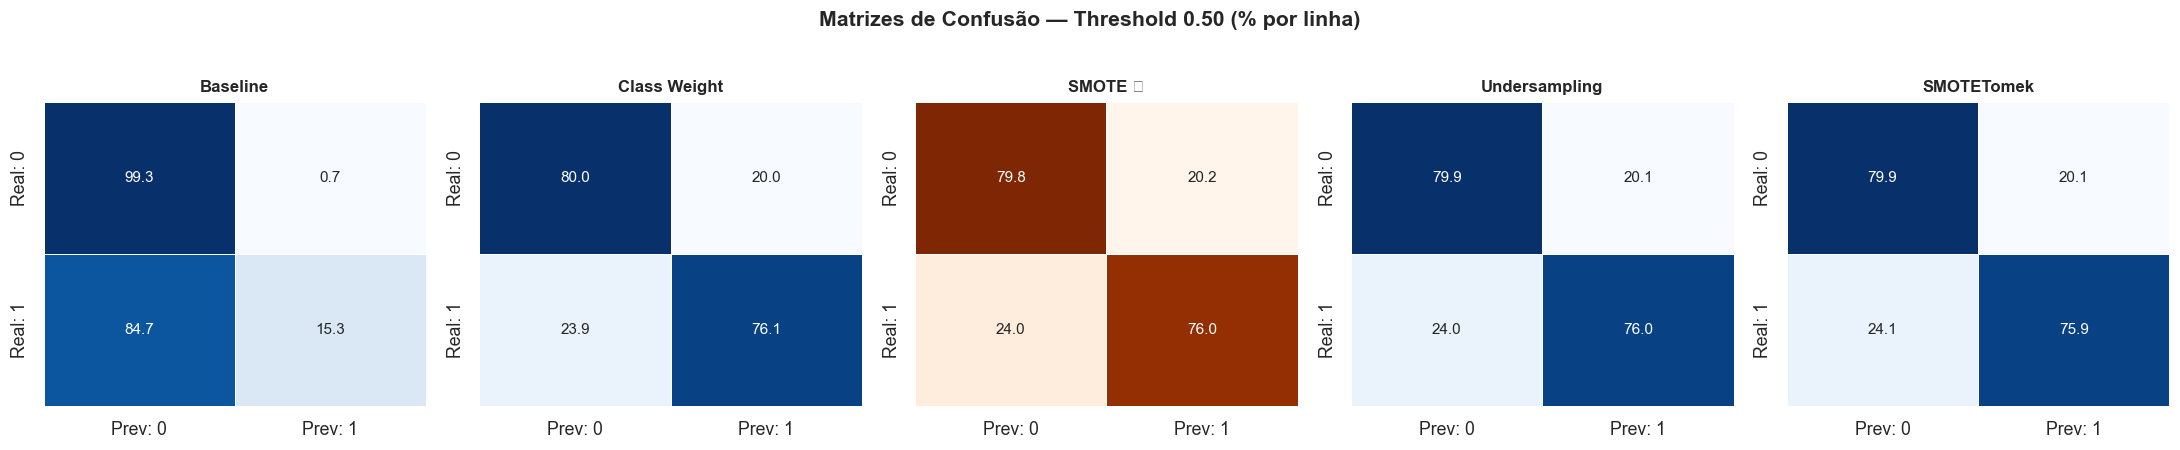

In [14]:
n = len(results)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))

for ax, (name, m) in zip(axes, results.items()):
    y_pred = (m['y_proba'] >= 0.5).astype(int)
    cm_pct = confusion_matrix(y, y_pred).astype(float)
    cm_pct = cm_pct / cm_pct.sum(axis=1, keepdims=True) * 100

    cmap = 'Oranges' if name == CHOSEN_STRATEGY else 'Blues'
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap=cmap, ax=ax,
                xticklabels=['Prev: 0', 'Prev: 1'],
                yticklabels=['Real: 0', 'Real: 1'],
                linewidths=0.5, linecolor='white', cbar=False,
                annot_kws={'size': 10})
    title_suffix = ' ⭐' if name == CHOSEN_STRATEGY else ''
    ax.set_title(f'{name}{title_suffix}', fontsize=11, fontweight='bold')

plt.suptitle('Matrizes de Confusão — Threshold 0.50 (% por linha)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## 5. Justificativa da Escolha: SMOTE

O experimento comparativo confirma a escolha do SMOTE como estratégia de balanceamento. A decisão é sustentada por dois critérios complementares:

**Critério técnico:**
- SMOTE gera amostras **sintéticas** da classe minoritária interpolando entre vizinhos próximos no espaço de features — o modelo aprende padrões reais dos inadimplentes, não apenas repete os mesmos exemplos
- Em comparação com `class_weight`, o SMOTE tende a produzir **maior Recall** na classe 1 — crítico em risco de crédito, onde Falso Negativo tem custo financeiro direto
- Em comparação com Undersampling, o SMOTE **preserva toda a informação** da classe majoritária (~140k registros), sem descartar dados relevantes

**Critério de portfólio / rastreabilidade:**
- O dataset balanceado exportado (~50% de cada classe) torna o efeito do balanceamento **explícito e visível** em `05_modelagem.ipynb`
- A estratégia é **independente do algoritmo** de modelagem — qualquer modelo no `05` recebe o mesmo dataset balanceado, tornando a comparação entre eles mais justa
- `class_weight='balanced'` depende de cada modelo suportar esse parâmetro; SMOTE não tem essa limitação

> **Nota sobre `class_weight`:** esta abordagem continua disponível como parâmetro adicional nos modelos que o suportam (LR, RF, LightGBM) dentro do `05_modelagem.ipynb`, funcionando como uma segunda camada de ajuste sobre o dataset já balanceado.

### 5.1 Análise de Threshold para o SMOTE

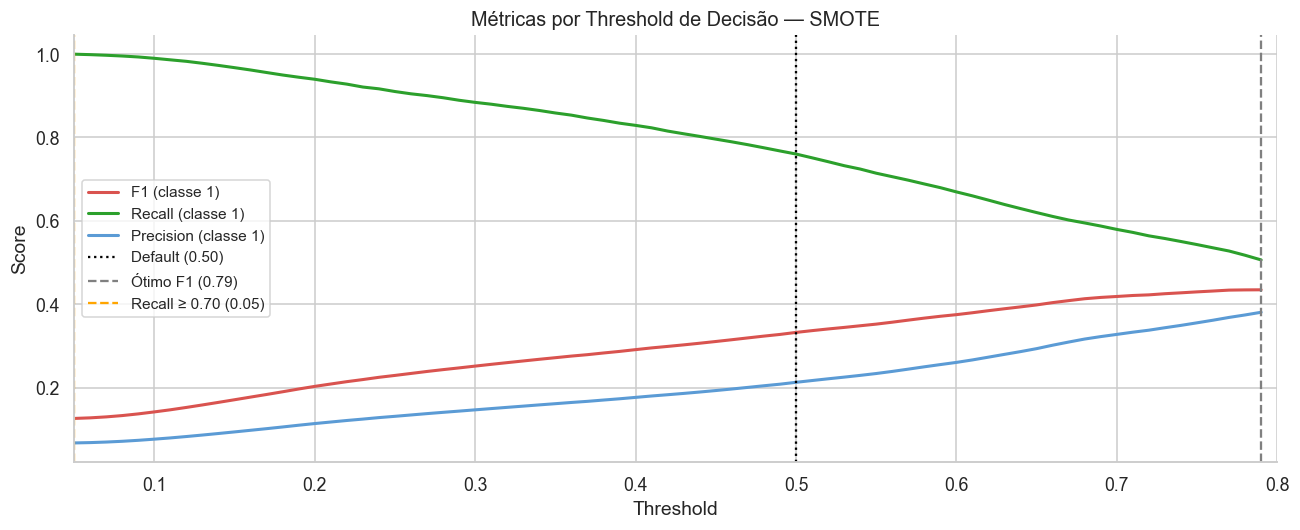

Threshold ótimo (max F1):       0.79  →  F1=0.4346 | Recall=0.5063 | Precision=0.3807
Threshold (Recall ≥ 0.70):      0.05  →  F1=0.1260 | Recall=0.9998 | Precision=0.0672

📌 O threshold final será calibrado em 06_avaliacao.ipynb após a
   seleção do modelo definitivo — a decisão é de negócio, não de modelo.


In [15]:
y_proba_smote = results['SMOTE']['y_proba']
thresholds    = np.arange(0.05, 0.80, 0.01)

f1_list, recall_list, prec_list = [], [], []
for t in thresholds:
    yp = (y_proba_smote >= t).astype(int)
    f1_list.append(f1_score(y, yp, pos_label=1, zero_division=0))
    recall_list.append(recall_score(y, yp, pos_label=1, zero_division=0))
    prec_list.append(precision_score(y, yp, pos_label=1, zero_division=0))

idx_f1  = int(np.argmax(f1_list))
thr_f1  = thresholds[idx_f1]
idx_r70 = next((i for i, r in enumerate(recall_list) if r >= 0.70), None)
thr_r70 = thresholds[idx_r70] if idx_r70 is not None else None

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(thresholds, f1_list,     color=COLOR_1,   lw=2, label='F1 (classe 1)')
ax.plot(thresholds, recall_list, color='#2ca02c', lw=2, label='Recall (classe 1)')
ax.plot(thresholds, prec_list,   color=COLOR_0,   lw=2, label='Precision (classe 1)')
ax.axvline(0.50,   color='black',  ls=':',  lw=1.5, label='Default (0.50)')
ax.axvline(thr_f1, color='gray',   ls='--', lw=1.5, label=f'Ótimo F1 ({thr_f1:.2f})')
if thr_r70:
    ax.axvline(thr_r70, color='orange', ls='--', lw=1.5,
               label=f'Recall ≥ 0.70 ({thr_r70:.2f})')
ax.set_title('Métricas por Threshold de Decisão — SMOTE', fontsize=13)
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.legend(fontsize=10)
ax.set_xlim(0.05, 0.80)
plt.tight_layout()
plt.show()

print(f'Threshold ótimo (max F1):       {thr_f1:.2f}'
      f'  →  F1={f1_list[idx_f1]:.4f} | Recall={recall_list[idx_f1]:.4f} | '
      f'Precision={prec_list[idx_f1]:.4f}')
if thr_r70:
    print(f'Threshold (Recall ≥ 0.70):      {thr_r70:.2f}'
          f'  →  F1={f1_list[idx_r70]:.4f} | Recall={recall_list[idx_r70]:.4f} | '
          f'Precision={prec_list[idx_r70]:.4f}')
print()
print('📌 O threshold final será calibrado em 06_avaliacao.ipynb após a')
print('   seleção do modelo definitivo — a decisão é de negócio, não de modelo.')

---

## 6. Geração do Dataset de Treino Balanceado

Aplicamos o SMOTE ao conjunto completo para gerar o dataset de treino equilibrado que será consumido por `05_modelagem.ipynb`.

> **Importante:** este é o único momento em que o SMOTE é aplicado ao dataset completo.  
> Em `05_modelagem.ipynb`, dentro do pipeline de cada modelo, o SMOTE **não deve ser reaplicado** — o dataset já chega balanceado.

In [16]:
print('Aplicando SMOTE ao dataset completo...')
print(f'Antes  → {len(y):,} amostras  |  '
      f'classe 0: {(y==0).sum():,}  |  classe 1: {(y==1).sum():,}')

scaler      = StandardScaler()
X_scaled    = scaler.fit_transform(X)

smote       = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_bal_arr, y_bal = smote.fit_resample(X_scaled, y)

X_bal = pd.DataFrame(X_bal_arr, columns=FEATURES)
y_bal = pd.Series(y_bal, name=TARGET)

print(f'Depois → {len(y_bal):,} amostras  |  '
      f'classe 0: {(y_bal==0).sum():,}  |  classe 1: {(y_bal==1).sum():,}')
print()
print('Proporção após balanceamento:')
print(y_bal.value_counts(normalize=True).mul(100).round(2))

Aplicando SMOTE ao dataset completo...
Antes  → 149,999 amostras  |  classe 0: 139,973  |  classe 1: 10,026
Depois → 279,946 amostras  |  classe 0: 139,973  |  classe 1: 139,973

Proporção após balanceamento:
target_default_2y
1   50.0000
0   50.0000
Name: proportion, dtype: float64


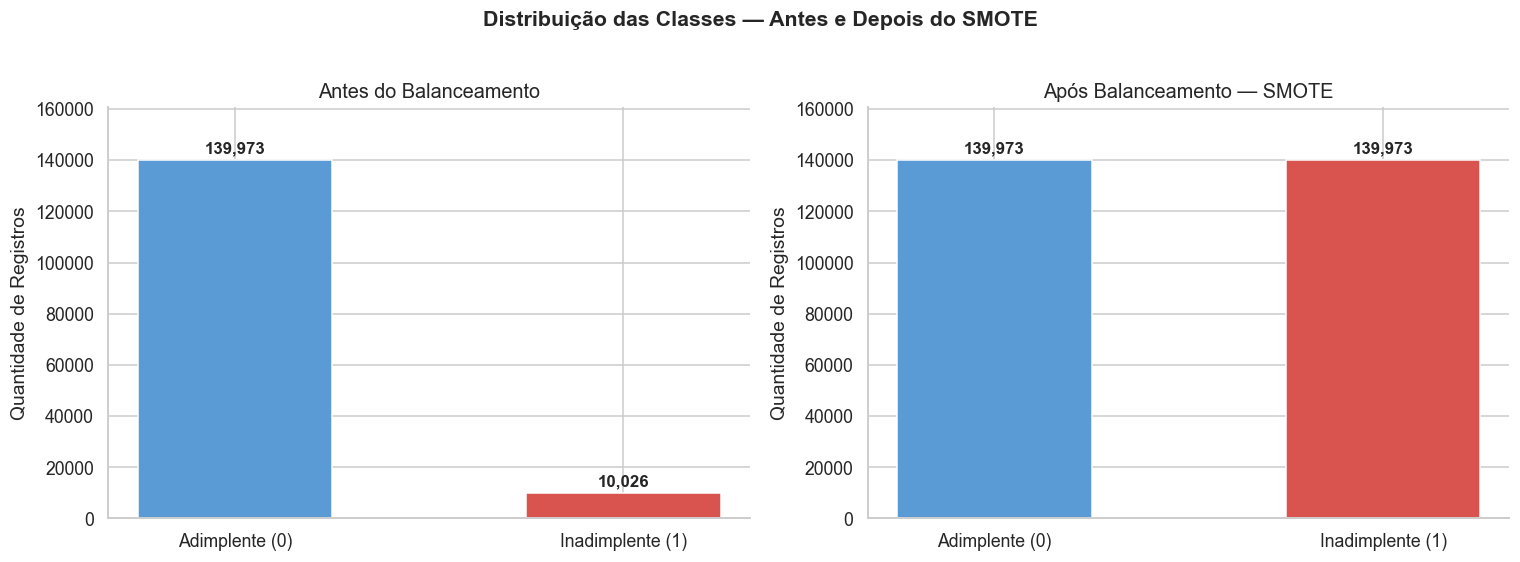

In [17]:
# Visualização antes × depois
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

datasets = [
    (y,    'Antes do Balanceamento'),
    (y_bal, 'Após Balanceamento — SMOTE'),
]

for ax, (series, title) in zip(axes, datasets):
    counts = series.value_counts().sort_index()
    bars = ax.bar(
        ['Adimplente (0)', 'Inadimplente (1)'],
        counts.values,
        color=[COLOR_0, COLOR_1], edgecolor='white', width=0.5
    )
    ax.set_title(title, fontsize=13)
    ax.set_ylabel('Quantidade de Registros')
    ax.set_ylim(0, max(counts.values) * 1.15)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(counts.values) * 0.02,
                f'{bar.get_height():,}',
                ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Distribuição das Classes — Antes e Depois do SMOTE',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

> O SMOTE gerou amostras sintéticas da classe minoritária interpolando entre vizinhos próximos no espaço de features.  
> O dataset de treino agora tem ~50% de cada classe, garantindo que os modelos em `05_modelagem.ipynb` aprendam com uma representação equilibrada das duas populações.

---

## 7. Exportação

In [18]:
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../models',         exist_ok=True)

# Dataset balanceado
df_bal = X_bal.copy()
df_bal[TARGET] = y_bal.values

output_data = '../data/processed/cs-training_balanced.parquet'
df_bal.to_parquet(output_data, index=False)

# Configuração da estratégia
config = {
    'balancing_strategy'       : CHOSEN_STRATEGY,
    'smote_k_neighbors'        : 5,
    'threshold_reference_f1'   : float(round(thr_f1, 2)),
    'threshold_reference_r70'  : float(round(thr_r70, 2)) if thr_r70 else None,
    'n_samples_before'         : int(len(y)),
    'n_samples_after'          : int(len(y_bal)),
    'class_distribution_before': {int(k): int(v) for k, v in y.value_counts().items()},
    'class_distribution_after' : {int(k): int(v) for k, v in y_bal.value_counts().items()},
    'features'                 : FEATURES,
    'target'                   : TARGET,
    'cv_strategy'              : 'StratifiedKFold(n_splits=5)',
    'random_state'             : RANDOM_STATE,
    'score_weights'            : WEIGHTS,
    'strategy_comparison'      : {
        name: {k: round(float(m[k]), 4) for k in METRIC_KEYS if k != 'y_proba'}
        for name, m in results.items()
        for METRIC_KEYS in [['AUC-ROC', 'PR-AUC', 'F1 (classe 1)',
                              'Recall (cl. 1)', 'Precision (cl. 1)']]
    },
}

output_cfg = '../models/balancing_config.json'
with open(output_cfg, 'w') as f:
    json.dump(config, f, indent=2)

print(f'✅ Dataset balanceado exportado → {output_data}')
print(f'   Amostras: {len(df_bal):,}  |  Colunas: {df_bal.shape[1]}')
print()
print(f'✅ Configuração exportada        → {output_cfg}')
print(f'   Estratégia: {CHOSEN_STRATEGY}')
print(f'   Threshold de referência (F1 ótimo): {thr_f1:.2f}')

✅ Dataset balanceado exportado → ../data/processed/cs-training_balanced.parquet
   Amostras: 279,946  |  Colunas: 19

✅ Configuração exportada        → ../models/balancing_config.json
   Estratégia: SMOTE
   Threshold de referência (F1 ótimo): 0.79


---

## 8. Conclusões

### 📊 Resumo das Estratégias Avaliadas

| Estratégia | Altera os dados? | Prós | Contras |
|---|---|---|---|
| **Baseline** | Não | Referência | Ignora classe minoritária |
| **Class Weight** | Não | Simples; funciona em produção | Recall mais conservador; depende do modelo suportar |
| **SMOTE ⭐** | Sim — oversampling | Dataset ~50/50; independente do modelo; alto Recall | Gera dados sintéticos; pode interpoler ruído |
| **Undersampling** | Sim — reduz maioria | Rápido | Descarta ~130k registros reais |
| **SMOTETomek** | Sim — híbrido | Balanceia + limpa fronteiras | Mais lento |

### 📦 Artefatos Gerados

| Arquivo | Descrição |
|---|---|
| `data/processed/cs-training_balanced.parquet` | Dataset com ~50% de cada classe, pronto para `05_modelagem` |
| `models/balancing_config.json` | Parâmetros, métricas e thresholds de referência |

### ➡️ Próximos passos em `05_modelagem.ipynb`

- Carregar `cs-training_balanced.parquet` diretamente — **não aplicar SMOTE novamente**
- Treinar: Regressão Logística, Decision Tree, Random Forest, XGBoost, LightGBM e PyCaret (AutoML)
- `class_weight='balanced'` pode ser usado como parâmetro **adicional** nos modelos que o suportam

---
> 📁 Próximo notebook: `05_modelagem.ipynb`